In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

from torchmetrics.classification import BinaryJaccardIndex
from torchsummary import summary

import imageio
from skimage.morphology import dilation, remove_small_objects, area_closing, area_opening, erosion, disk
from skimage.filters import median, threshold_local, rank, threshold_otsu
import matplotlib.pyplot as plt

In [54]:
from PIL import Image

seed_val = 674

torch.manual_seed(seed_val)
torch.cuda.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.enabled=False
torch.backends.cudnn.benchmark = False

In [110]:
class SSLNet(nn.Module):
    
    def __init__(self, in_channels, out_channels):
        super(SSLNet, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.mid_level = nn.Sequential(
            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
#             nn.MaxPool2d(2, 2)
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(128, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, out_channels, kernel_size=2, stride=2, output_padding=0)
        )

    def forward(self, x):
        x1 = self.encoder(x)
        x2 = self.mid_level(x1)
        x3 = self.decoder(x2)

        return x3
    

In [111]:
# model = SSLNet(4, 1)
# summary(model.to('cuda'), (4, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]           1,184
              ReLU-2         [-1, 32, 128, 128]               0
            Conv2d-3         [-1, 32, 128, 128]           9,248
              ReLU-4         [-1, 32, 128, 128]               0
         MaxPool2d-5           [-1, 32, 64, 64]               0
            Conv2d-6           [-1, 64, 64, 64]          18,496
              ReLU-7           [-1, 64, 64, 64]               0
            Conv2d-8           [-1, 64, 64, 64]          36,928
              ReLU-9           [-1, 64, 64, 64]               0
           Conv2d-10           [-1, 96, 64, 64]          55,392
             ReLU-11           [-1, 96, 64, 64]               0
           Conv2d-12           [-1, 96, 64, 64]          83,040
             ReLU-13           [-1, 96, 64, 64]               0
           Conv2d-14          [-1, 128,

In [112]:
# # /localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t000_ch00_std.png
# # /localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t001_ch00_std.png
# # /localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t002_ch00_std.png
# # /localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t003_ch00_std.png
# # /localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t004_ch00_std.png

# import imageio

# filenames = [f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t0{x:02d}_ch00_std.png' for x in range(100)]

# arrays = [imageio.imread(file_path) for file_path in filenames]

# in_stacks = [arrays[i:i+4] for i in range(0, len(arrays), 5) if i + 4 <= len(arrays)]

# mask_stacks = [arrays[i] for i in range(4, len(arrays), 5)]

In [156]:
def get_stacks(group, n, seq):
    groups = {'ATL':'A', 'Climp':'C', 'Control':'Ct', 'RTN':'R'}
    filenames = [f'/localhome/asa420/MIAL/data/confocal-data/{group}/std/{groups[group]}{seq}_decon_t0{x:02d}_ch00_std.png' for x in range(100)]
    arrays = [imageio.imread(file_path) for file_path in filenames]
    in_stacks = [arrays[i:i+n] for i in range(0, len(arrays), n+1)]
    mask_stacks = [arrays[i] for i in range(n, len(arrays), n+1)]
    return in_stacks, mask_stacks

In [174]:
# create n channel stacks to predict frame at n+1 (mask)

def get_proc_stacks(group, n, seq):
    groups = {'ATL':'A', 'Climp':'C', 'Control':'Ct', 'RTN':'R'}
    filenames = [f'/localhome/asa420/MIAL/data/confocal-data/{group}/preproc/{groups[group]}{seq}/{groups[group]}{seq}_decon_t0{x:02d}_ch00_proc.png' for x in range(100)]
    arrays = [imageio.imread(file_path) for file_path in filenames]
    in_stacks = [arrays[i:i+n] for i in range(0, len(arrays), n+1)]
    mask_stacks = [arrays[i] for i in range(n, len(arrays), n+1)]
    return in_stacks, mask_stacks

In [175]:
in_data = []
mask_data = []
for seq in range(1, 27):
    in_stacks, mask_stacks = get_proc_stacks('ATL', seq)
    in_data.extend(in_stacks)
    mask_data.extend(mask_stacks)
in_data = np.array(in_data)
mask_data = np.array(mask_data)

In [176]:
in_data.shape

(130, 19, 128, 128)

In [177]:
mask_data = np.expand_dims(mask_data, 1)

In [178]:
mask_data.shape

(130, 1, 128, 128)

In [203]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

class SSLDataset(Dataset):
    def __init__(self, in_stacks, mask_stacks, transform=None):
        self.in_stacks = in_stacks
        self.mask_stacks = mask_stacks
        self.transform = transform

    def __len__(self):
        return len(self.in_stacks)

    def __getitem__(self, idx):
        in_stack = torch.Tensor(self.in_stacks[idx])
        mask_stack = torch.Tensor(self.mask_stacks[idx])

        return in_stack, mask_stack

transform = transforms.Compose([
    transforms.ToTensor()
])

# Create the custom dataset
dataset = SSLDataset(in_data, mask_data, transform=transform)

# Create the data loader
batch_size = 16  # Adjust the batch size as needed
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [204]:
# train on stack of 19 frames to predict 20th

in_channels = 19
out_channels = 1

model = SSLNet(in_channels, out_channels)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training loop
num_epochs = 200
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    for inputs, masks in train_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, masks)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print the training loss for each epoch
    print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {loss.item()}")
    
# jacc = BinaryJaccardIndex().to(device)
# total_iou = 0
    
# Testing loop
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, masks in test_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, masks)
        test_loss += loss.item()
        
#         batch_iou = jacc(outputs, masks).item()
#         total_iou += batch_iou

# Calculate and print the average test loss
average_test_loss = test_loss / len(test_loader)
print(f"Average Test Loss: {average_test_loss}")

# print(f"Mean IoU: {total_iou/ len(test_loader)}")
torch.save(model.state_dict(), 'SSL_frames.pth')

Epoch [1/200], Training Loss: 1415.748046875
Epoch [2/200], Training Loss: 1027.018310546875
Epoch [3/200], Training Loss: 712.1845092773438
Epoch [4/200], Training Loss: 550.3387451171875
Epoch [5/200], Training Loss: 597.1228637695312
Epoch [6/200], Training Loss: 412.31390380859375
Epoch [7/200], Training Loss: 317.81011962890625
Epoch [8/200], Training Loss: 379.60009765625
Epoch [9/200], Training Loss: 291.08636474609375
Epoch [10/200], Training Loss: 251.3247528076172
Epoch [11/200], Training Loss: 344.0633544921875
Epoch [12/200], Training Loss: 243.39132690429688
Epoch [13/200], Training Loss: 381.0281982421875
Epoch [14/200], Training Loss: 232.97702026367188
Epoch [15/200], Training Loss: 326.1822509765625
Epoch [16/200], Training Loss: 200.04147338867188
Epoch [17/200], Training Loss: 177.75381469726562
Epoch [18/200], Training Loss: 126.55949401855469
Epoch [19/200], Training Loss: 143.76780700683594
Epoch [20/200], Training Loss: 148.34414672851562
Epoch [21/200], Training

Epoch [167/200], Training Loss: 45.899864196777344
Epoch [168/200], Training Loss: 47.163780212402344
Epoch [169/200], Training Loss: 38.74327087402344
Epoch [170/200], Training Loss: 45.06568908691406
Epoch [171/200], Training Loss: 58.10205078125
Epoch [172/200], Training Loss: 29.37356185913086
Epoch [173/200], Training Loss: 44.114158630371094
Epoch [174/200], Training Loss: 37.926883697509766
Epoch [175/200], Training Loss: 35.14246368408203
Epoch [176/200], Training Loss: 44.236907958984375
Epoch [177/200], Training Loss: 39.1811408996582
Epoch [178/200], Training Loss: 34.04795455932617
Epoch [179/200], Training Loss: 40.832462310791016
Epoch [180/200], Training Loss: 34.62568664550781
Epoch [181/200], Training Loss: 57.48275375366211
Epoch [182/200], Training Loss: 51.47383117675781
Epoch [183/200], Training Loss: 39.94493103027344
Epoch [184/200], Training Loss: 44.5184211730957
Epoch [185/200], Training Loss: 35.574928283691406
Epoch [186/200], Training Loss: 41.7865295410156

In [212]:
test_samples = next(iter(test_loader))

In [213]:
test_samples[0].shape

torch.Size([16, 19, 128, 128])

In [214]:
test_samples[1].shape

torch.Size([16, 1, 128, 128])

In [215]:
def viz_model_outputs(test_samples, k):
    ip = test_samples[0][k]
    ip = ip.unsqueeze(0)

    # Forward pass through the model
    model.eval()
    with torch.no_grad():
        output = model(ip.to(device))

    # Convert the output to probabilities by applying the sigmoid activation
    output_probs = torch.sigmoid(output)
    # type(output_probs)

    # Convert tensors to numpy arrays for visualization
    image_np = ip.squeeze().numpy()
    output_probs_np = output_probs.cpu().squeeze().numpy()
    return output_probs_np

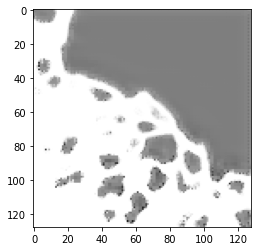

In [216]:
op1 = viz_model_outputs(test_samples, 5)
plt.imshow(op1, cmap='gray')

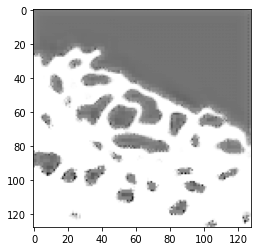

In [217]:
op2 = viz_model_outputs(test_samples, 10)
plt.imshow(op2, cmap='gray')